In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import missingno as msno
from mpl_toolkits.mplot3d import Axes3D

<h1>Data Exploration</h1>

In [120]:
df=pd.read_csv(f'hotel_bookings.csv')
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [122]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [123]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [124]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


<h3>Checking Missing Values</h3>

In [125]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


<Axes: >

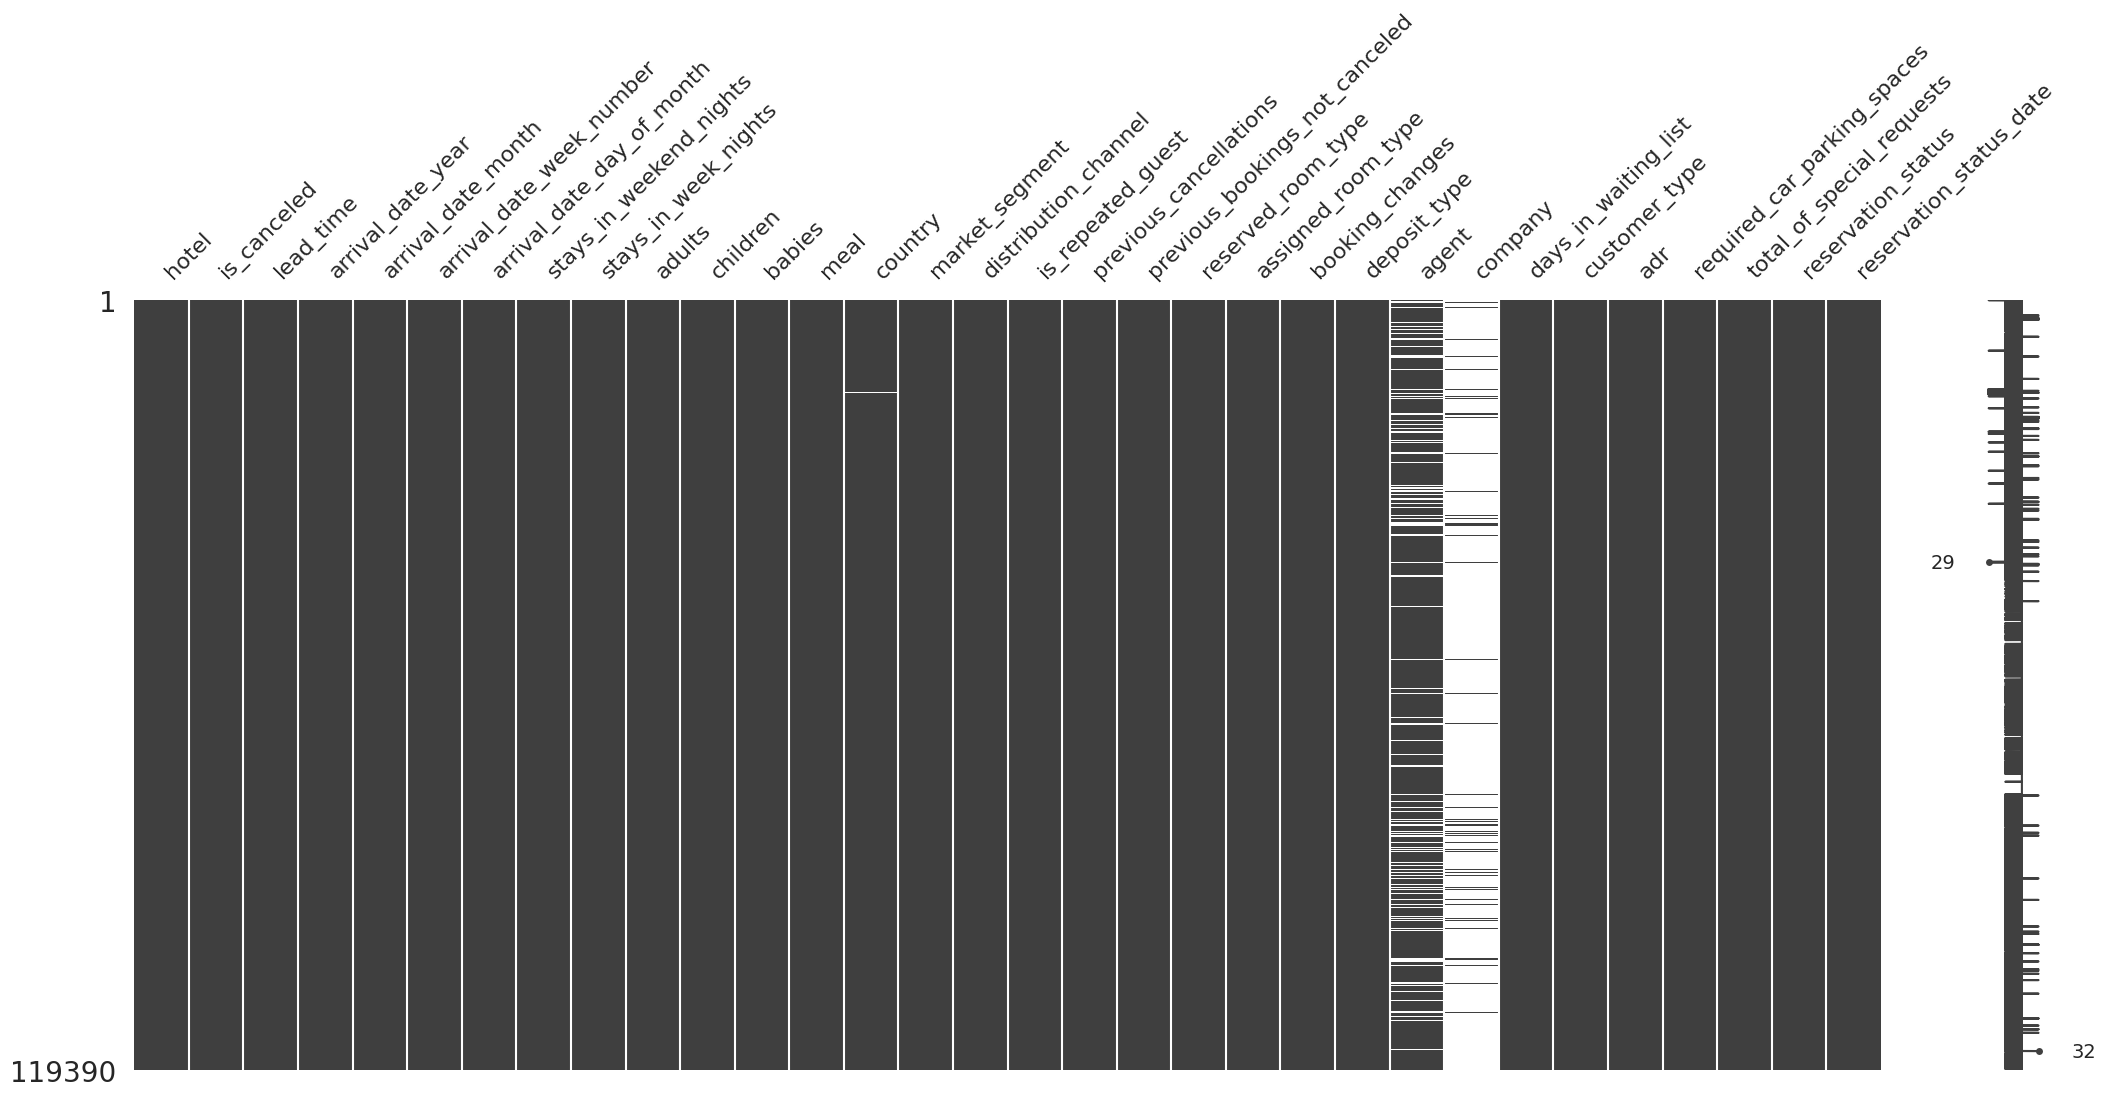

In [126]:
## To check the missing values
msno.matrix(df)

<Axes: >

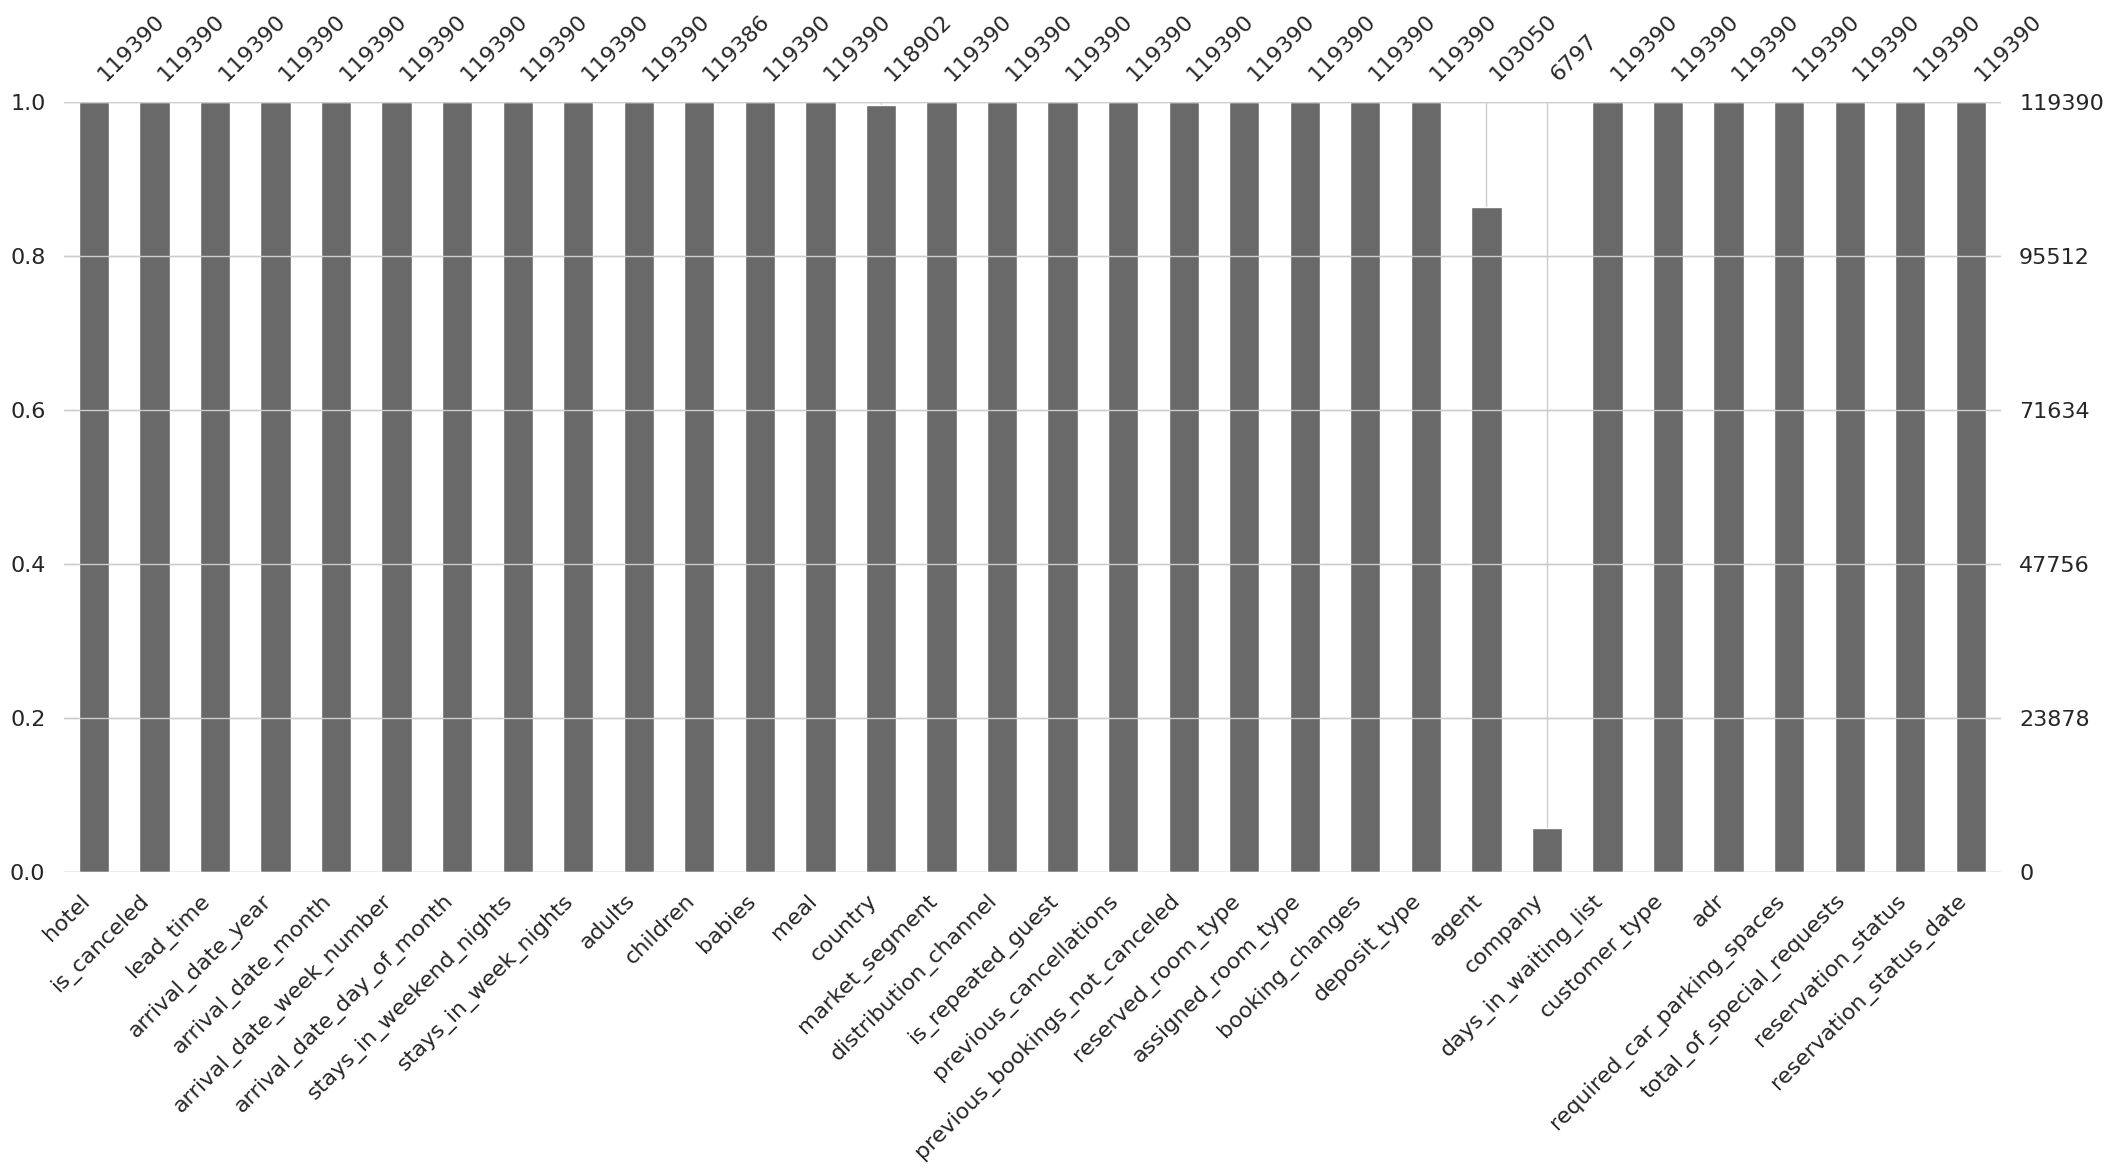

In [127]:
## How many values are present per column
msno.bar(df)

<Axes: >

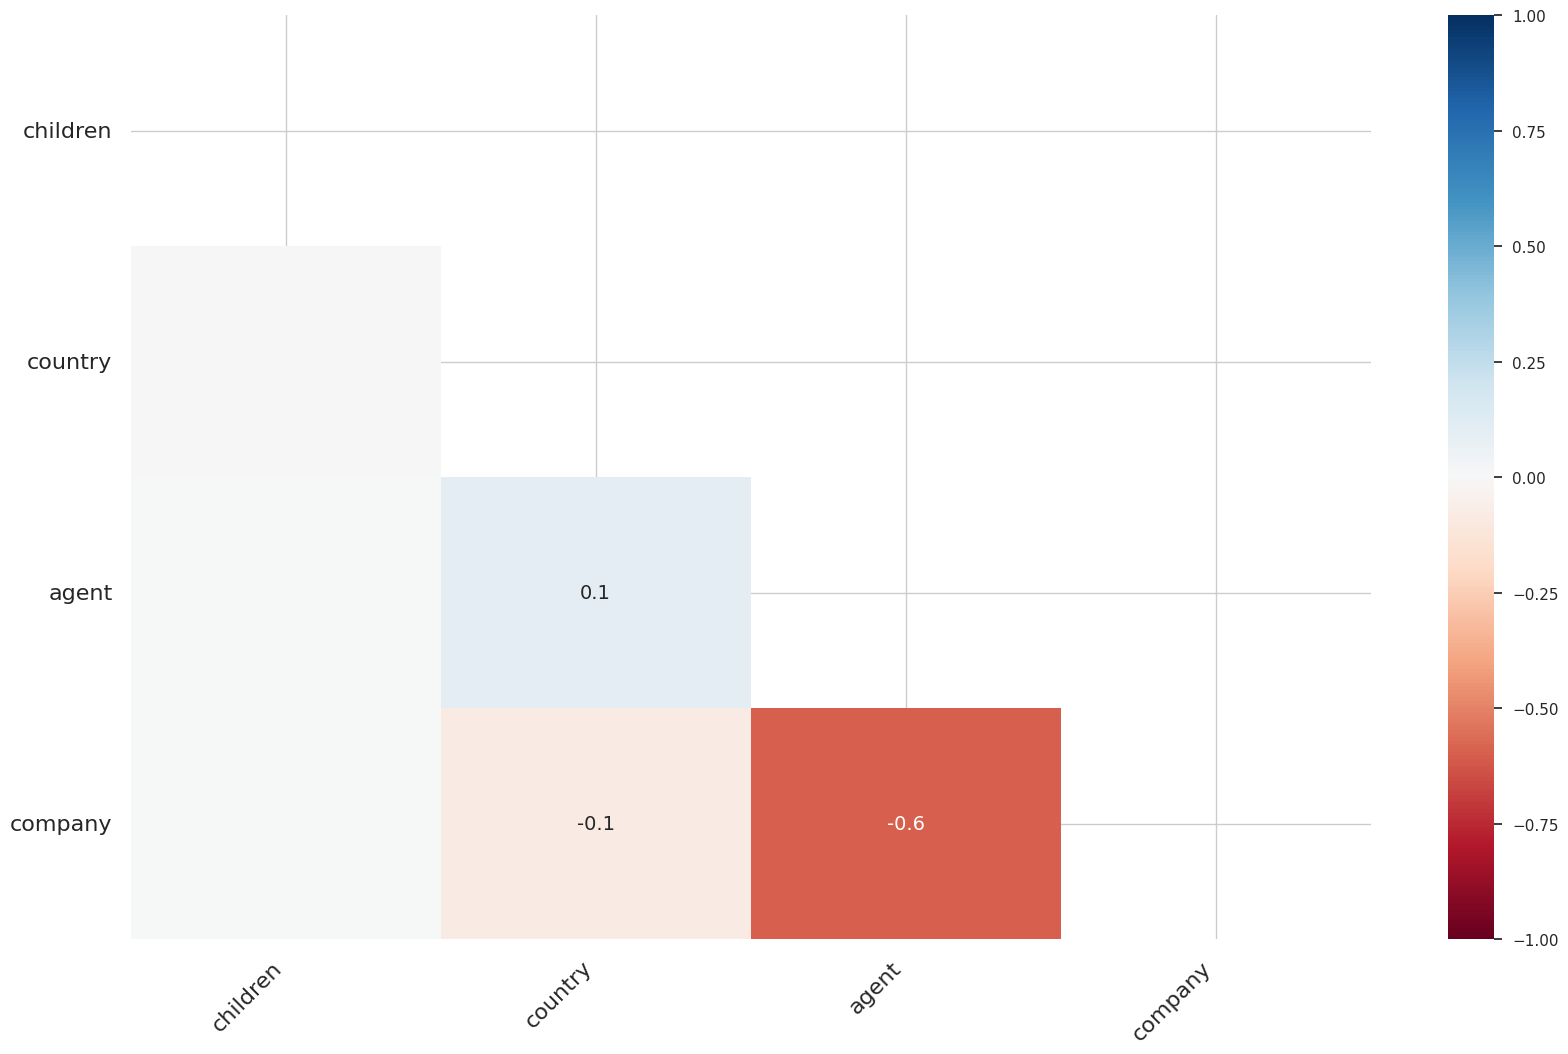

In [128]:
# How strongly two or more columns (with missing values) are related
msno.heatmap(df)
#A -0.6 correlation means a moderately strong inverse relationship between company and agent.

In [129]:
# The NaN values are changed to "Unknown". We don't want to delete the columns / rows because we want to preserve all the information.
# Since the three columns "country", "agent" and "company" are categorical, we replace null values with "Unknown"
categorical_cols = ['country', 'agent', 'company']
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
# There are 4 missing values for children we replace them with 0
df['children'] = df['children'].fillna(0)
#Verifying if still null values are present
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [130]:
#Check which columns are categorical and which are numeric
# Get numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("No. of numeric columns: ", len(numeric_cols))
print("-------------------")
print("Categorical columns:", categorical_cols)
print("No. of numeric columns: ", len(categorical_cols))

Numeric columns: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
No. of numeric columns:  18
-------------------
Categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'agent', 'company', 'customer_type', 'reservation_status', 'reservation_status_date']
No. of numeric columns:  14


<h1>Data Preprocessing</h1>

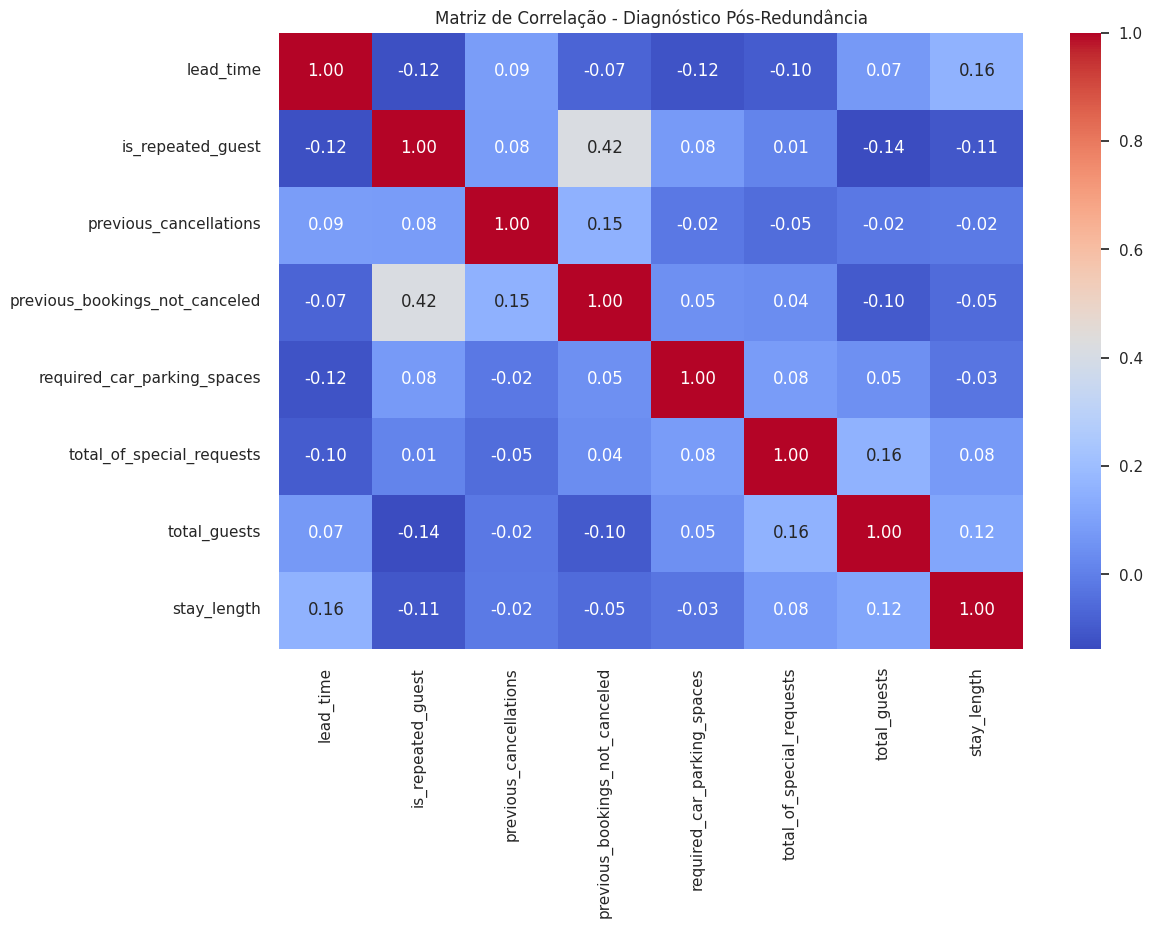

--- PIPELINE CONCLUÍDO ---
Shape final: (119390, 64)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 64 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lead_time                       119390 non-null  float64
 1   total_guests                    119390 non-null  float64
 2   stay_length                     119390 non-null  float64
 3   is_repeated_guest               119390 non-null  float64
 4   previous_cancellations          119390 non-null  float64
 5   previous_bookings_not_canceled  119390 non-null  float64
 6   required_car_parking_spaces     119390 non-null  float64
 7   total_of_special_requests       119390 non-null  float64
 8   hotel_City Hotel                119390 non-null  float64
 9   hotel_Resort Hotel              119390 non-null  float64
 10  arrival_date_month_April        119390 non-null  float64
 11  arrival_date_month_August

In [131]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ==========================================
# 1. CARREGAMENTO E LIMPEZA INICIAL (Anti-Leakage)
# ==========================================
# Carregar o dataset original
df = pd.read_csv("hotel_bookings.csv")

# Definição de colunas a remover:
# - Leakage (info do futuro)
# - IDs (sem valor estatístico)
# - Redundância temporal excessiva
drop_cols = [
    "is_canceled", "reservation_status", "reservation_status_date",
    "adr", "agent", "company", "arrival_date_year",
    "arrival_date_week_number", "arrival_date_day_of_month", "assigned_room_type",
    "booking_changes", "days_in_waiting_list"
]

df_cluster_raw = df.drop(columns=drop_cols).copy()

# ==========================================
# 2. ENGENHARIA DE VARIÁVEIS (Novas Features)
# ==========================================
# 1. Criar as variáveis agregadas (Unificadas)
df_cluster_raw["total_guests"] = df_cluster_raw["adults"] + df_cluster_raw["children"] + df_cluster_raw["babies"]
df_cluster_raw["stay_length"] = df_cluster_raw["stays_in_week_nights"] + df_cluster_raw["stays_in_weekend_nights"]

# 2. REMOVER AS ORIGINAIS (Aqui é que matas a redundância)
# Removemos as partes para ficar apenas com o todo
cols_redundantes = ["adults", "children", "babies", "stays_in_week_nights", "stays_in_weekend_nights"]
df_cluster_raw = df_cluster_raw.drop(columns=cols_redundantes)

# ==========================================
# 3. VISUALIZAÇÃO DE CORRELAÇÃO (Ponto 5 - Redundancy)
# ==========================================
plt.figure(figsize=(12, 8))
# Agora o heatmap só vai mostrar 'total_guests' e 'stay_length', sem as antigas!
corr = df_cluster_raw.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação - Diagnóstico Pós-Redundância")
plt.show()

# ==========================================
# 4. TRATAMENTO DE ALTA CARDINALIDADE (Custom Transformer)
# ==========================================
class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Agrupa categorias que aparecem em menos de X% dos dados como 'Other'"""
    def __init__(self, threshold=0.01):
        self.threshold = threshold
        self.frequent_categories_ = {}

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        for col in X.columns:
            counts = X[col].value_counts(normalize=True)
            self.frequent_categories_[col] = counts[counts >= self.threshold].index.tolist()
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in X.columns:
            X[col] = X[col].apply(lambda x: x if x in self.frequent_categories_[col] else 'Other')
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features

# ==========================================
# 5. DEFINIÇÃO DE COLUNAS PARA O PREPROCESSOR
# ==========================================
# Nota: total_guests e stay_length ficam de fora do treino para não viciar distâncias
numeric_features = [
    'lead_time',
    'total_guests',               # <--- Nova (Ocupação total)
    'stay_length',                # <--- Nova (Noites totais)
    'is_repeated_guest',
    'previous_cancellations',
    'previous_bookings_not_canceled',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

categorical_features = [
    'hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
    'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type'
]

# ==========================================
# 6. PIPELINE DE TRANSFORMAÇÃO (Standardize + OneHot)
# ==========================================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('rare_grouper', RareCategoryGrouper(threshold=0.01)),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# ==========================================
# 7. EXECUÇÃO FINAL: df_preprocessed
# ==========================================
X_processed_array = preprocessor.fit_transform(df_cluster_raw)

# Converter de volta para DataFrame para inspeção
cat_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
final_columns = numeric_features + list(cat_cols)

df_preprocessed = pd.DataFrame(X_processed_array, columns=final_columns)

print("--- PIPELINE CONCLUÍDO ---")
print(f"Shape final: {df_preprocessed.shape}")
df_preprocessed.info()

Após a engenharia de variáveis e a remoção das colunas redundantes ('adults', 'children', 'babies' e estadias parciais), a nova matriz de correlação revela a ausência de multicolinearidade crítica. Isto demonstra que as variáveis selecionadas são independentes e oferecem informação complementar, otimizando a performance do algoritmo de clustering e cumprindo os requisitos de não-redundância definidos.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


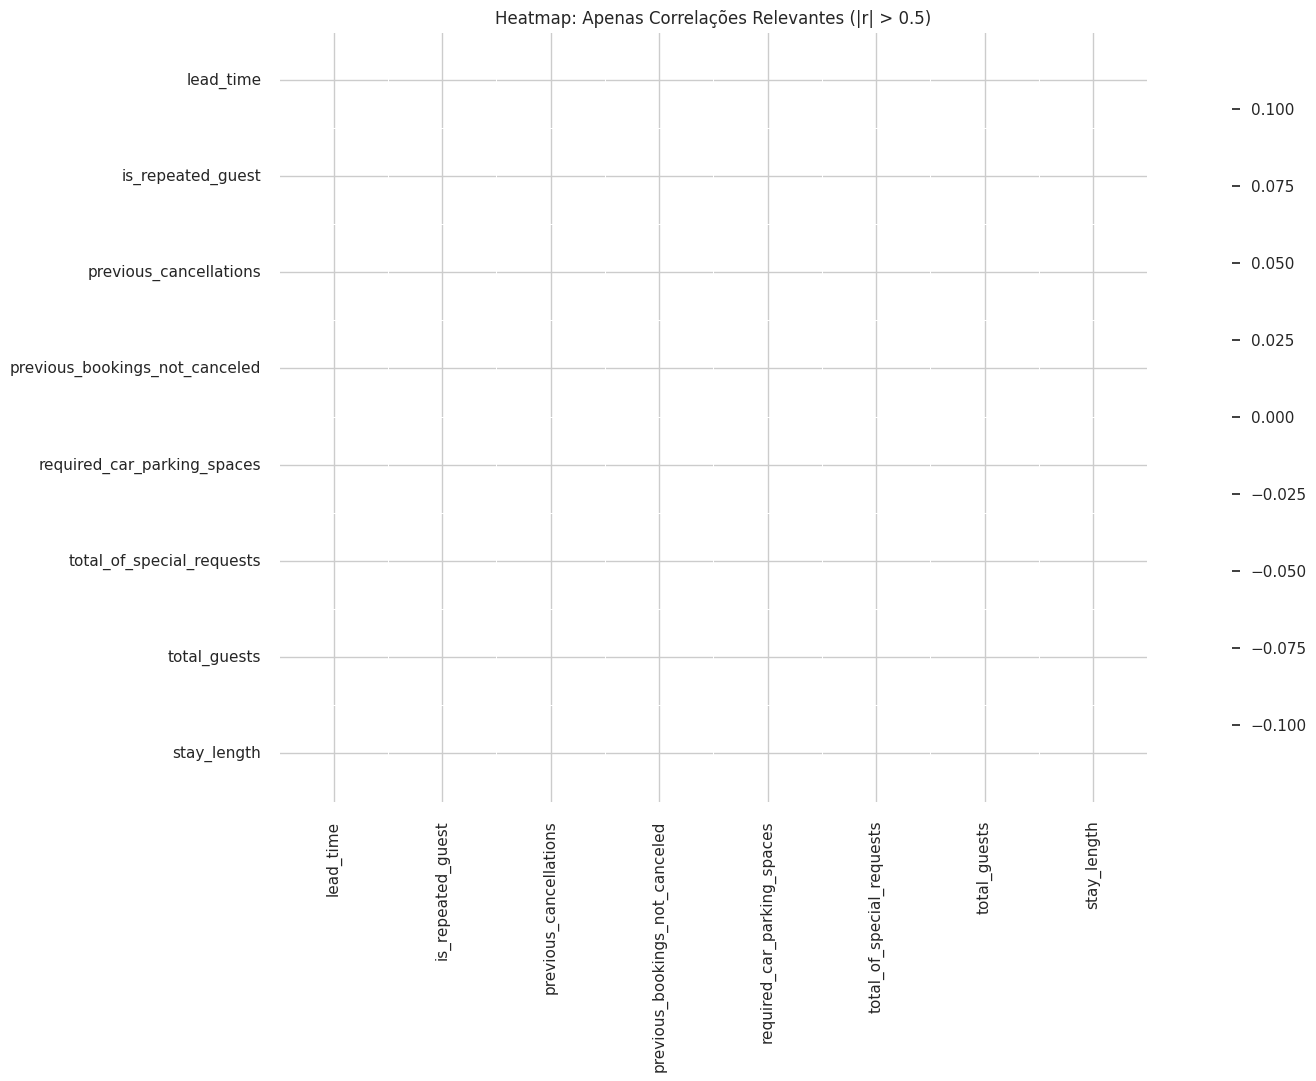

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir o que consideras uma "correlação que importa"
threshold = 0.5

# 2. Calcular a matriz de correlação completa
corr_matrix = df_cluster_raw.corr(numeric_only=True)

# 3. Criar a MÁSCARA
# Vamos esconder (True) tudo o que for menor que o threshold
# E também esconder a diagonal principal (correlação 1.0 consigo mesma)
mask = np.abs(corr_matrix) < threshold
np.fill_diagonal(mask.values, True)

# 4. Desenhar o Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,           # Aqui está o segredo: ele só pinta o que não estiver na máscara
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title(f"Heatmap: Apenas Correlações Relevantes (|r| > {threshold})")
plt.show()

O heatmap com threshold de 0.5 resultou vazio, o que valida a eficácia da remoção de redundância. Nenhuma variável apresenta multicolinearidade, garantindo que o algoritmo de clustering não será enviesado por informação duplicada.

In [133]:
def report_outliers(df, columns):
    outlier_data = []
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = len(df[(df[col] < lower) | (df[col] > upper)])
        percentage = (count / len(df)) * 100
        outlier_data.append([col, count, f"{percentage:.2f}%"])

    return pd.DataFrame(outlier_data, columns=['Coluna', 'Nº Outliers', '% do Total'])

# Executar para as tuas colunas numéricas
outlier_summary = report_outliers(df_cluster_raw, numeric_features)
print(outlier_summary)

                           Coluna  Nº Outliers % do Total
0                       lead_time         3005      2.52%
1                    total_guests        37338     31.27%
2                     stay_length         5257      4.40%
3               is_repeated_guest         3810      3.19%
4          previous_cancellations         6484      5.43%
5  previous_bookings_not_canceled         3620      3.03%
6     required_car_parking_spaces         7416      6.21%
7       total_of_special_requests         2877      2.41%


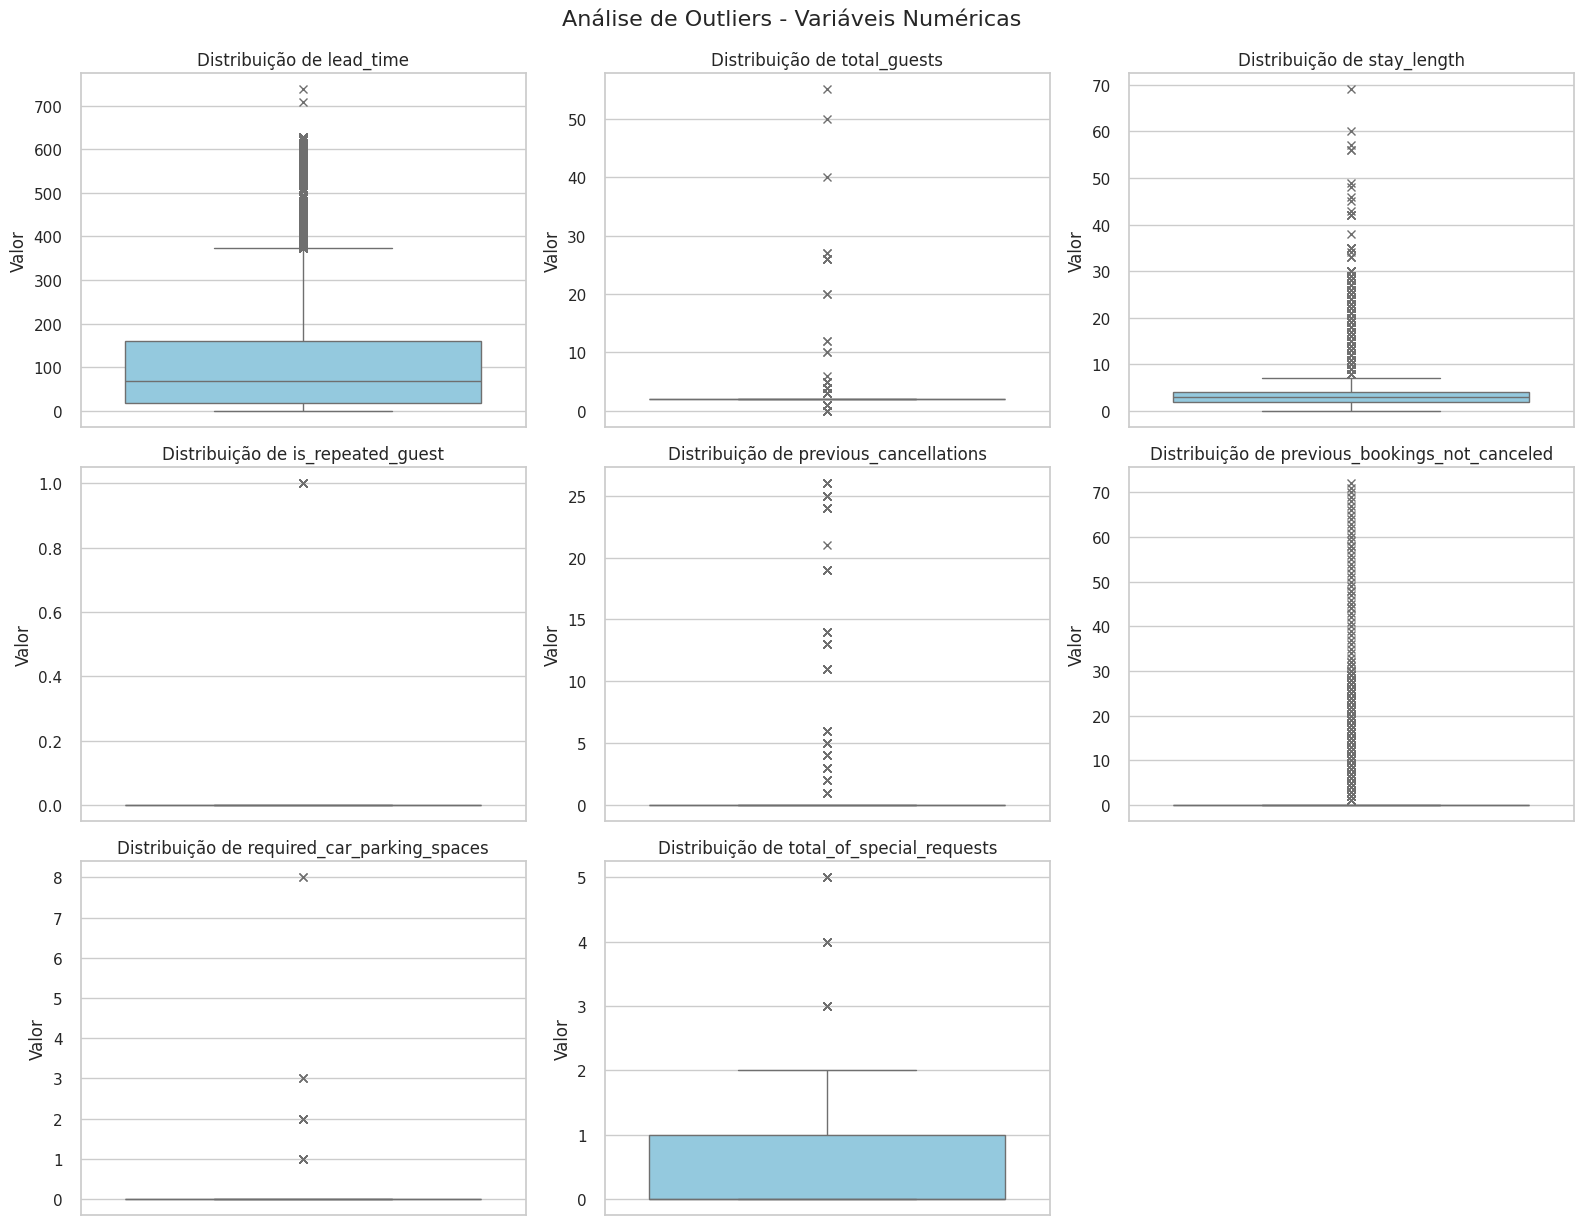

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar o estilo e o tamanho da figura
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

# 2. Criar um subplot para cada variável numérica
for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1) # Cria uma grelha de 3x3
    sns.boxplot(y=df_cluster_raw[col], color='skyblue', flierprops={"marker": "x", "markerfacecolor": "red"})
    plt.title(f"Distribuição de {col}", fontsize=12)
    plt.ylabel("Valor")

# 3. Ajustar o layout para não haver sobreposição
plt.tight_layout()
plt.suptitle("Análise de Outliers - Variáveis Numéricas", fontsize=16, y=1.02)
plt.show()

In [135]:
def apply_capping(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        upper_limit = Q3 + 1.5 * IQR
        lower_limit = Q1 - 1.5 * IQR

        # Fazemos o capping (winsorização)
        df_capped[col] = np.clip(df_capped[col], lower_limit, upper_limit)
    return df_capped

# Aplicar o capping antes de ir para o df_preprocessed
df_cluster_raw = apply_capping(df_cluster_raw, numeric_features)

In [136]:
df_cluster_raw.head()

,hotel,lead_time,arrival_date_month,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,deposit_type,customer_type,required_car_parking_spaces,total_of_special_requests,total_guests,stay_length
0,Resort Hotel,342,July,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0.0,2.0,0
1,Resort Hotel,373,July,BB,PRT,Direct,Direct,0,0,0,C,No Deposit,Transient,0,0.0,2.0,0
2,Resort Hotel,7,July,BB,GBR,Direct,Direct,0,0,0,A,No Deposit,Transient,0,0.0,2.0,1
3,Resort Hotel,13,July,BB,GBR,Corporate,Corporate,0,0,0,A,No Deposit,Transient,0,0.0,2.0,1
4,Resort Hotel,14,July,BB,GBR,Online TA,TA/TO,0,0,0,A,No Deposit,Transient,0,1.0,2.0,2


In [137]:
df_cluster_raw.describe()

,lead_time,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,required_car_parking_spaces,total_of_special_requests,total_guests,stay_length
count,119390.000000,119390.0,119390.0,119390.0,119390.0,119390.000000,119386.0,119390.000000
mean,102.229157,0.0,0.0,0.0,0.0,0.555796,2.0,3.237390
std,101.158934,0.0,0.0,0.0,0.0,0.744655,0.0,1.869468
min,0.000000,0.0,0.0,0.0,0.0,0.000000,2.0,0.000000
25%,18.000000,0.0,0.0,0.0,0.0,0.000000,2.0,2.000000
50%,69.000000,0.0,0.0,0.0,0.0,0.000000,2.0,3.000000
75%,160.000000,0.0,0.0,0.0,0.0,1.000000,2.0,4.000000
max,373.000000,0.0,0.0,0.0,0.0,2.500000,2.0,7.000000


In [138]:
#Check which columns are categorical and which are numeric
# Get numeric columns
numeric_cols = df_preprocessed.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Get categorical columns
categorical_cols = df_preprocessed.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric columns:", numeric_cols)
print("No. of numeric columns: ", len(numeric_cols))
print("-------------------")
print("Categorical columns:", categorical_cols)
print("No. of numeric columns: ", len(categorical_cols))

Numeric columns: ['lead_time', 'total_guests', 'stay_length', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'required_car_parking_spaces', 'total_of_special_requests', 'hotel_City Hotel', 'hotel_Resort Hotel', 'arrival_date_month_April', 'arrival_date_month_August', 'arrival_date_month_December', 'arrival_date_month_February', 'arrival_date_month_January', 'arrival_date_month_July', 'arrival_date_month_June', 'arrival_date_month_March', 'arrival_date_month_May', 'arrival_date_month_November', 'arrival_date_month_October', 'arrival_date_month_September', 'meal_BB', 'meal_HB', 'meal_Other', 'meal_SC', 'country_AUT', 'country_BEL', 'country_BRA', 'country_CHE', 'country_CN', 'country_DEU', 'country_ESP', 'country_FRA', 'country_GBR', 'country_IRL', 'country_ITA', 'country_NLD', 'country_Other', 'country_PRT', 'country_USA', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online

In [156]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 65 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lead_time                       119390 non-null  float64
 1   total_guests                    119390 non-null  float64
 2   stay_length                     119390 non-null  float64
 3   is_repeated_guest               119390 non-null  float64
 4   previous_cancellations          119390 non-null  float64
 5   previous_bookings_not_canceled  119390 non-null  float64
 6   required_car_parking_spaces     119390 non-null  float64
 7   total_of_special_requests       119390 non-null  float64
 8   hotel_City Hotel                119390 non-null  float64
 9   hotel_Resort Hotel              119390 non-null  float64
 10  arrival_date_month_April        119390 non-null  float64
 11  arrival_date_month_August       119390 non-null  float64
 12  arrival_date_mon

**clustering atributes**- hotel, lead_time, arrival_date_month (ou época do ano), stays_in_weekend_nights, stays_in_week_nights, adults, children, babies, country, market_segment, distribution_channel, deposit_type, customer_type, is_repeated_guest, previous_cancellations, reserved_room_type

**profiling atributtes**-adr,required_car_parking_spaces,total_of_special_requests,meal



 **TO prevente data LEAKAGE do not use this to cluster:**
is_canceled,
reservation_status,
reservation_status_date
,assigned_room_type
,
booking_changes,
days_in_waiting_list.

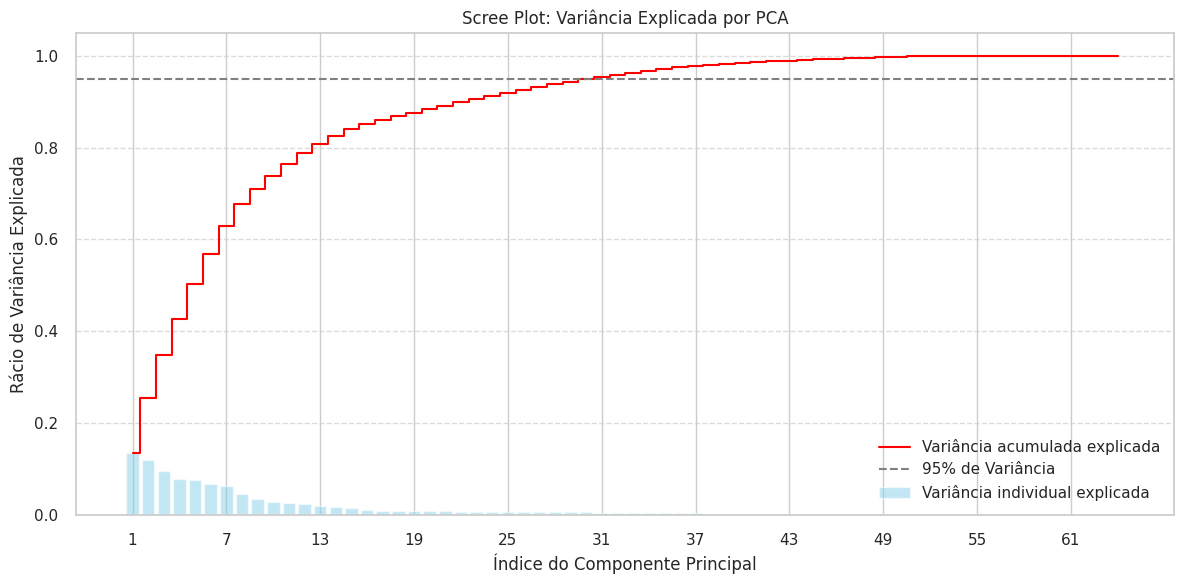

Número de componentes necessários para explicar 95% da variância: 31


In [139]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# 1. Configurar o PCA
# Se o df_preprocessed for uma matriz esparsa (comum após OneHotEncoder),
# precisamos de a converter para densa ou usar TruncatedSVD.
# Aqui assumimos que queres ver todos os componentes possíveis.
data_to_pca = df_preprocessed.toarray() if hasattr(df_preprocessed, "toarray") else df_preprocessed

pca = PCA()
pca.fit(data_to_pca)

# 2. Calcular a variância explicada
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

# 3. Criar a visualização
plt.figure(figsize=(12, 6))

# Barras para a variância individual
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.5, align='center',
        label='Variância individual explicada', color='skyblue')

# Linha para a variância acumulada
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid',
         label='Variância acumulada explicada', color='red')

# Linha de referência nos 95% (opcional, para ajudar na decisão)
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% de Variância')

plt.ylabel('Rácio de Variância Explicada')
plt.xlabel('Índice do Componente Principal')
plt.title('Scree Plot: Variância Explicada por PCA')
plt.xticks(np.arange(1, len(exp_var_pca) + 1, step=max(1, len(exp_var_pca)//10)))
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar e mostrar
plt.savefig('pca_explained_variance.png')
plt.show()

# Print para ajudar na decisão técnica
n_95 = np.argmax(cum_sum_eigenvalues >= 0.95) + 1
print(f"Número de componentes necessários para explicar 95% da variância: {n_95}")

In [140]:
# Optional PCA for dimensionality reduction before K-Means explain at least 95 of the variance
# -------------------------
pca_before_kmeans = PCA(n_components=n_95, random_state=42)
X_reduced = pca_before_kmeans.fit_transform(df_preprocessed)

WITHOUT PCA

A iniciar cálculo de Silhouette com amostragem de 20.0% por cluster...


/tmp/ipykernel_6545/2641560236.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=2 | Amostra: 23878 pontos (20.0%) | Silhouette: 0.3770


/tmp/ipykernel_6545/2641560236.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=3 | Amostra: 23877 pontos (20.0%) | Silhouette: 0.1219


...

K=8 | Amostra: 23878 pontos (20.0%) | Silhouette: 0.1432


/tmp/ipykernel_6545/2641560236.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=9 | Amostra: 23878 pontos (20.0%) | Silhouette: 0.1482


/tmp/ipykernel_6545/2641560236.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=10 | Amostra: 23879 pontos (20.0%) | Silhouette: 0.1365


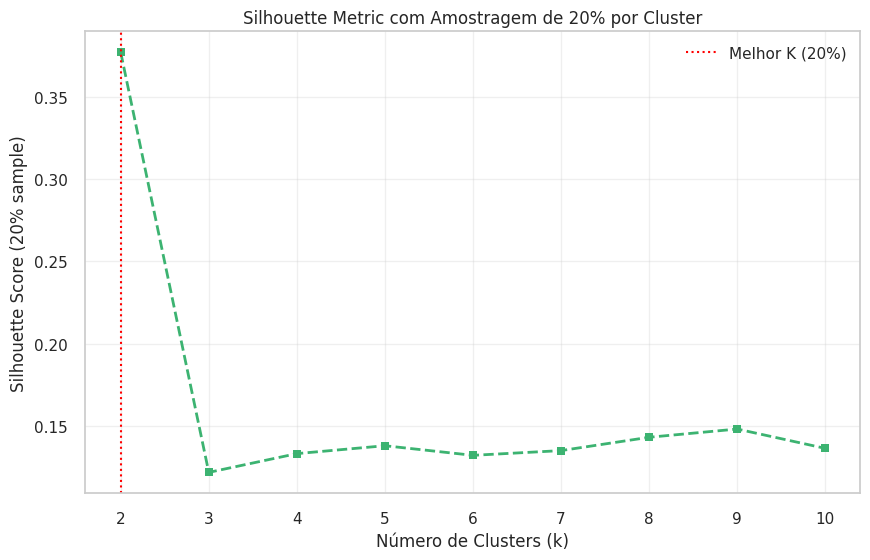


O veredito final com 20% de cada cluster é: k=2


In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Configurações
k_range = range(2, 11)
percent_silhouette_scores = []
sampling_ratio = 0.20  # Os teus 20%

print(f"A iniciar cálculo de Silhouette com amostragem de {sampling_ratio*100}% por cluster...")

for k in k_range:
    # A. Treinar o KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(df_preprocessed)

    # B. Preparar os dados para amostragem
    X_temp = df_preprocessed.toarray() if hasattr(df_preprocessed, "toarray") else X_reduced
    df_temp = pd.DataFrame(X_temp)
    df_temp['cluster'] = cluster_labels

    # C. Amostragem Estratificada de 20% por cada grupo
    df_sample = (df_temp.groupby('cluster', group_keys=False)
                 .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))

    # D. Isolar amostra e labels
    X_sample = df_sample.drop(columns=['cluster']).values
    labels_sample = df_sample['cluster'].values

    # E. Calcular Silhouette
    score = silhouette_score(X_sample, labels_sample)
    percent_silhouette_scores.append(score)

    print(f"K={k} | Amostra: {len(labels_sample)} pontos ({sampling_ratio*100}%) | Silhouette: {score:.4f}")

# 2. Visualização
plt.figure(figsize=(10, 6))
plt.plot(k_range, percent_silhouette_scores, marker='s', linestyle='--', color='mediumseagreen', linewidth=2)
plt.axvline(x=k_range[np.argmax(percent_silhouette_scores)], color='red', linestyle=':', label='Melhor K (20%)')

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score (20% sample)')
plt.title('Silhouette Metric com Amostragem de 20% por Cluster')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_k_20 = k_range[np.argmax(percent_silhouette_scores)]
print(f"\nO veredito final com 20% de cada cluster é: k={best_k_20}")

The silhouette method performs better in dimension reduction!!!

A iniciar cálculo de Silhouette com amostragem de 20.0% por cluster...


/tmp/ipykernel_6545/2471778088.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=2 | Amostra: 23878 pontos (20.0%) | Silhouette: 0.5158


/tmp/ipykernel_6545/2471778088.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=3 | Amostra: 23878 pontos (20.0%) | Silhouette: 0.1213


...

K=8 | Amostra: 23879 pontos (20.0%) | Silhouette: 0.1439


/tmp/ipykernel_6545/2471778088.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=9 | Amostra: 23879 pontos (20.0%) | Silhouette: 0.1492


/tmp/ipykernel_6545/2471778088.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=10 | Amostra: 23879 pontos (20.0%) | Silhouette: 0.1368


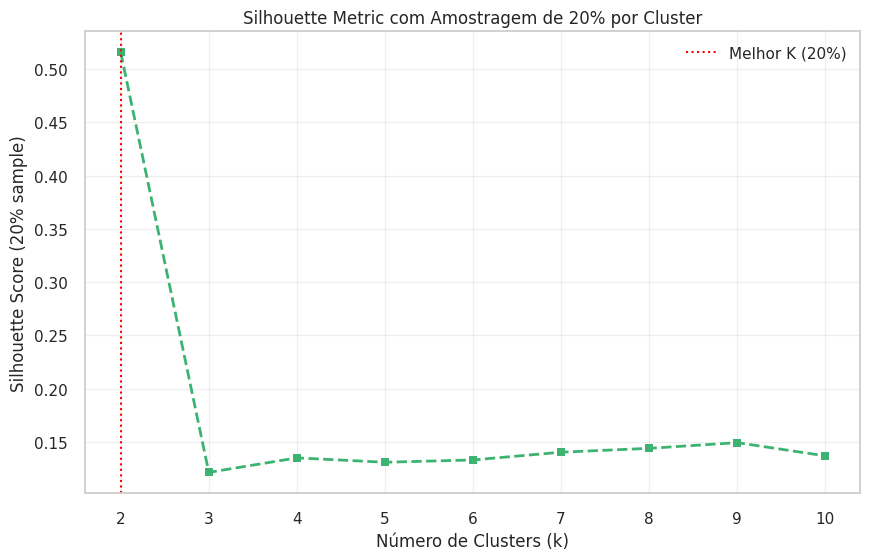


O veredito final com 20% de cada cluster é: k=2


In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Configurações
k_range = range(2, 11)
percent_silhouette_scores = []
sampling_ratio = 0.20  # Os teus 20%

print(f"A iniciar cálculo de Silhouette com amostragem de {sampling_ratio*100}% por cluster...")

for k in k_range:
    # A. Treinar o KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_reduced)

    # B. Preparar os dados para amostragem
    X_temp = X_reduced.toarray() if hasattr(X_reduced, "toarray") else X_reduced
    df_temp = pd.DataFrame(X_temp)
    df_temp['cluster'] = cluster_labels

    # C. Amostragem Estratificada de 20% por cada grupo
    df_sample = (df_temp.groupby('cluster', group_keys=False)
                 .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))

    # D. Isolar amostra e labels
    X_sample = df_sample.drop(columns=['cluster']).values
    labels_sample = df_sample['cluster'].values

    # E. Calcular Silhouette
    score = silhouette_score(X_sample, labels_sample)
    percent_silhouette_scores.append(score)

    print(f"K={k} | Amostra: {len(labels_sample)} pontos ({sampling_ratio*100}%) | Silhouette: {score:.4f}")

# 2. Visualização
plt.figure(figsize=(10, 6))
plt.plot(k_range, percent_silhouette_scores, marker='s', linestyle='--', color='mediumseagreen', linewidth=2)
plt.axvline(x=k_range[np.argmax(percent_silhouette_scores)], color='red', linestyle=':', label='Melhor K (20%)')

plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score (20% sample)')
plt.title('Silhouette Metric com Amostragem de 20% por Cluster')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

best_k_20 = k_range[np.argmax(percent_silhouette_scores)]
print(f"\nO veredito final com 20% de cada cluster é: k={best_k_20}")

awsome level silhouette!!! almost 0.5

A iniciar avaliação total (4 métricas) com amostragem de 20.0% por cluster...


/tmp/ipykernel_6545/606722332.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=2 processado.


/tmp/ipykernel_6545/606722332.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=3 processado.


...

K=8 processado.


/tmp/ipykernel_6545/606722332.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=9 processado.


/tmp/ipykernel_6545/606722332.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))


K=10 processado.


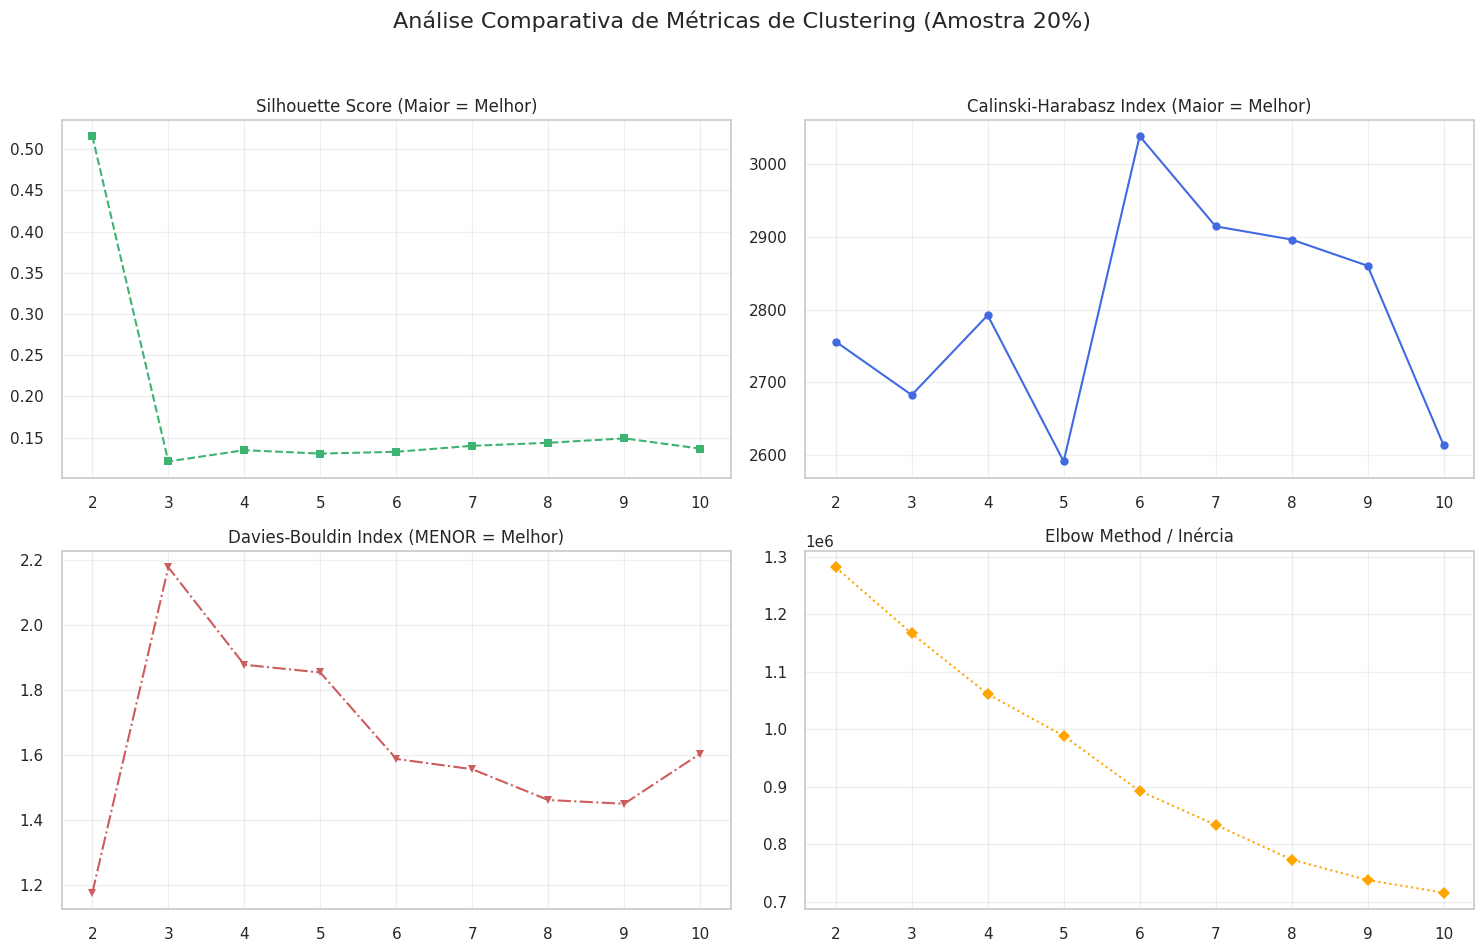


Melhor K (Silhouette): 2
Melhor K (Calinski):   6
Melhor K (Davies):     2


In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 1. Configurações
k_range = range(2, 11)
silhouette_scores = []
calinski_scores = []
davies_scores = []
inertia_scores = []
sampling_ratio = 0.20

print(f"A iniciar avaliação total (4 métricas) com amostragem de {sampling_ratio*100}% por cluster...")

for k in k_range:
    # A. Treinar o KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_reduced)

    # B. Preparar os dados para amostragem
    X_temp = X_reduced.toarray() if hasattr(X_reduced, "toarray") else X_reduced
    df_temp = pd.DataFrame(X_temp)
    df_temp['cluster'] = cluster_labels

    # C. Amostragem Estratificada de 20%
    df_sample = (df_temp.groupby('cluster', group_keys=False)
                 .apply(lambda x: x.sample(frac=sampling_ratio, random_state=42)))

    X_sample = df_sample.drop(columns=['cluster']).values
    labels_sample = df_sample['cluster'].values

    # D. Calcular as 4 Métricas
    silhouette_scores.append(silhouette_score(X_sample, labels_sample))
    calinski_scores.append(calinski_harabasz_score(X_sample, labels_sample))
    davies_scores.append(davies_bouldin_score(X_sample, labels_sample)) # Menor é melhor
    inertia_scores.append(kmeans.inertia_)

    print(f"K={k} processado.")

# 2. VISUALIZAÇÃO MULTIPLA
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# [0, 0] Silhouette (Maior é melhor)
axs[0, 0].plot(k_range, silhouette_scores, marker='s', color='mediumseagreen', linestyle='--')
axs[0, 0].set_title('Silhouette Score (Maior = Melhor)')
axs[0, 0].grid(True, alpha=0.3)

# [0, 1] Calinski-Harabasz (Maior é melhor)
axs[0, 1].plot(k_range, calinski_scores, marker='o', color='royalblue', linestyle='-')
axs[0, 1].set_title('Calinski-Harabasz Index (Maior = Melhor)')
axs[0, 1].grid(True, alpha=0.3)

# [1, 0] Davies-Bouldin (MENOR é melhor)
axs[1, 0].plot(k_range, davies_scores, marker='v', color='indianred', linestyle='-.')
axs[1, 0].set_title('Davies-Bouldin Index (MENOR = Melhor)')
axs[1, 0].grid(True, alpha=0.3)

# [1, 1] Inertia / Elbow (Menor é melhor)
axs[1, 1].plot(k_range, inertia_scores, marker='D', color='orange', linestyle=':')
axs[1, 1].set_title('Elbow Method / Inércia')
axs[1, 1].grid(True, alpha=0.3)

plt.suptitle('Análise Comparativa de Métricas de Clustering (Amostra 20%)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 3. VEREDITO FINAL
print("\n" + "="*30)
print(f"Melhor K (Silhouette): {k_range[np.argmax(silhouette_scores)]}")
print(f"Melhor K (Calinski):   {k_range[np.argmax(calinski_scores)]}")
print(f"Melhor K (Davies):     {k_range[np.argmin(davies_scores)]}") # Nota o argmin
print("="*30)

Silhouette method is stronger than elbow method since elbow just compute how much compact are each cluster,althought silhouette computes each point distance between centroids.

In [144]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 64 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   lead_time                       119390 non-null  float64
 1   total_guests                    119390 non-null  float64
 2   stay_length                     119390 non-null  float64
 3   is_repeated_guest               119390 non-null  float64
 4   previous_cancellations          119390 non-null  float64
 5   previous_bookings_not_canceled  119390 non-null  float64
 6   required_car_parking_spaces     119390 non-null  float64
 7   total_of_special_requests       119390 non-null  float64
 8   hotel_City Hotel                119390 non-null  float64
 9   hotel_Resort Hotel              119390 non-null  float64
 10  arrival_date_month_April        119390 non-null  float64
 11  arrival_date_month_August       119390 non-null  float64
 12  arrival_date_mon

In [157]:
# 1. FINALIZAR O MODELO
kmeans_final = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=42)
# Criamos os clusters usando os dados preparados (X_clustering ou X_pca)
clusters = kmeans_final.fit_predict(X_reduced)

# 2. ADICIONAR O CLUSTER AO DATASET ORIGINAL (Para leitura humana)
# Usamos o .copy() para não estragar a base original
df_profiling = df.copy()
df_profiling['cluster'] = clusters

# Criar também as colunas de apoio que calculaste antes
df_profiling["total_guests"] = df_profiling["adults"] + df_profiling["children"] + df_profiling["babies"]

# 3. DEFINIR AS VARIÁVEIS REAIS PARA O PROFILING
num_prof = ['adr', 'lead_time', 'total_of_special_requests', 'required_car_parking_spaces', 'total_guests']

# 4. PROFILING NUMÉRICO (Valores Reais em Euros, Dias, etc.)
print("### 1. MÉTRICAS DE VALOR E COMPORTAMENTO (Médias Reais) ###")
profiling_num = df_profiling.groupby('cluster')[num_prof].mean()
profiling_num['count'] = df_profiling['cluster'].value_counts()
display(profiling_num.round(2))

print("\n" + "-"*50 + "\n")

# 5. PROFILING DE RISCO (Taxa de Cancelamento Real)
print("### 2. TAXA DE CANCELAMENTO POR CLUSTER (%) ###")
cancel_rate = df_profiling.groupby('cluster')['is_canceled'].mean() * 100
display(cancel_rate.to_frame(name='Cancellation_Rate_%').round(2))

print("\n" + "-"*50 + "\n")

# 6. PROFILING CATEGÓRICO (Texto Legível: BB, HB, Online TA, etc.)
print("### 3. PREFERÊNCIAS DE REFEIÇÃO (MEAL) POR CLUSTER (%) ###")
meal_profile = df_profiling.groupby('cluster')['meal'].value_counts(normalize=True).unstack() * 100
display(meal_profile.fillna(0).round(2))

print("\n### 4. SEGMENTOS DE MERCADO POR CLUSTER (%) ###")
segment_profile = df_profiling.groupby('cluster')['market_segment'].value_counts(normalize=True).unstack() * 100
display(segment_profile.fillna(0).round(2))



# ---------------------------------------------------------
# ADICIONAR AO TEU CÓDIGO (DENTRO DA SECÇÃO DE PROFILING)
# ---------------------------------------------------------

# 7. PROFILING DE HOTEL (City vs Resort)
print("\n### 5. PREFERÊNCIA DE HOTEL POR CLUSTER (%) ###")
hotel_profile = df_profiling.groupby('cluster')['hotel'].value_counts(normalize=True).unstack() * 100
display(hotel_profile.round(2))

# 8. PROFILING DE CANAIS (Como reservam)
print("\n### 6. CANAIS DE DISTRIBUIÇÃO POR CLUSTER (%) ###")
dist_profile = df_profiling.groupby('cluster')['distribution_channel'].value_counts(normalize=True).unstack() * 100
display(dist_profile.fillna(0).round(2))

# 9. PROFILING DE PAÍS (Top 10 + Outros)
print("\n### 7. ORIGEM GEOGRÁFICA (TOP 10 PAÍSES) POR CLUSTER (%) ###")
# Identificar os 10 países com mais reservas no total
top_10_countries = df_profiling['country'].value_counts().nlargest(10).index

# Criar uma coluna temporária que agrupa o resto em 'Other'
df_profiling['country_grouped'] = df_profiling['country'].apply(lambda x: x if x in top_10_countries else 'Other')

country_profile = df_profiling.groupby('cluster')['country_grouped'].value_counts(normalize=True).unstack() * 100
# Reordenar para o 'Other' ficar no fim
cols = [c for c in country_profile.columns if c != 'Other'] + ['Other']
display(country_profile[cols].fillna(0).round(2))

### 1. MÉTRICAS DE VALOR E COMPORTAMENTO (Médias Reais) ###


,adr,lead_time,total_of_special_requests,required_car_parking_spaces,total_guests,count
cluster,,,,,,
0,103.08,106.45,0.57,0.06,1.99,115522
1,64.46,31.13,0.63,0.17,1.42,3868



--------------------------------------------------

### 2. TAXA DE CANCELAMENTO POR CLUSTER (%) ###


,Cancellation_Rate_%
cluster,
0,37.79
1,14.56



--------------------------------------------------

### 3. PREFERÊNCIAS DE REFEIÇÃO (MEAL) POR CLUSTER (%) ###


...

hotel,City Hotel,Resort Hotel
cluster,,
0,66.89,33.11
1,53.05,46.95



### 6. CANAIS DE DISTRIBUIÇÃO POR CLUSTER (%) ###


distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
cluster,,,,,
0,4.38,11.87,0.16,83.59,0.0
1,41.91,24.25,0.08,33.76,0.0



### 7. ORIGEM GEOGRÁFICA (TOP 10 PAÍSES) POR CLUSTER (%) ###


country_grouped,BEL,BRA,DEU,ESP,FRA,GBR,IRL,ITA,NLD,PRT,Other
cluster,,,,,,,,,,,
0,2.01,1.91,6.29,7.34,8.95,10.41,2.89,3.23,1.80,39.21,15.96
1,0.44,0.36,0.65,2.33,2.02,2.77,0.80,1.03,0.52,85.26,3.83


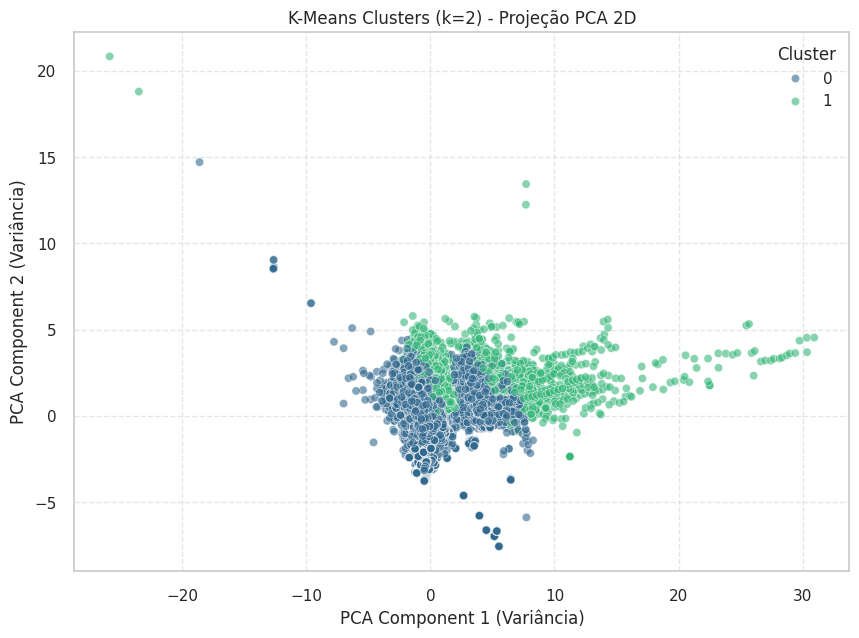

Tamanho de cada cluster:
cluster
0    111572
1      7818
Name: count, dtype: int64


In [146]:
# -------------------------
# 1. Fit K-Means com o df_preprocessed
# -------------------------
# Usamos o k=2 que os teus testes indicaram como o "vencedor" matemático
k = 2
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)

# O treino é feito SEMPRE nos dados standardizados (df_preprocessed)
cluster_labels = kmeans.fit_predict(df_preprocessed)

# -------------------------
# 2. Guardar os labels nos DataSets certos
# -------------------------
# No matemático (para gráficos de PCA)
df_preprocessed['cluster'] = cluster_labels

# No original/raw (para o Profiling humano que discutimos)
# Se já criaste o df_profiling a partir do df original, usa-o aqui:
df_profiling = df.copy()
df_profiling['cluster'] = cluster_labels
# Criar a coluna total_guests para a análise que falta
df_profiling["total_guests"] = df_profiling["adults"] + df_profiling["children"] + df_profiling["babies"]

# -------------------------
# 3. Visualizar clusters usando PCA (2D)
# -------------------------
# Importante: O PCA deve ser feito sobre os dados preprocessed (standardizados)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(df_preprocessed.drop(columns=['cluster']))

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca_2d[:, 0],
    y=X_pca_2d[:, 1],
    hue=df_preprocessed['cluster'],
    palette='viridis',
    alpha=0.6
)

plt.xlabel("PCA Component 1 (Variância)")
plt.ylabel("PCA Component 2 (Variância)")
plt.title(f"K-Means Clusters (k={k}) - Projeção PCA 2D")
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# -------------------------
# 4. Verificação Rápida de Profiling
# -------------------------
print("Tamanho de cada cluster:")
print(df_profiling['cluster'].value_counts())

A gerar Silhouette Plot (NumPy mode)...


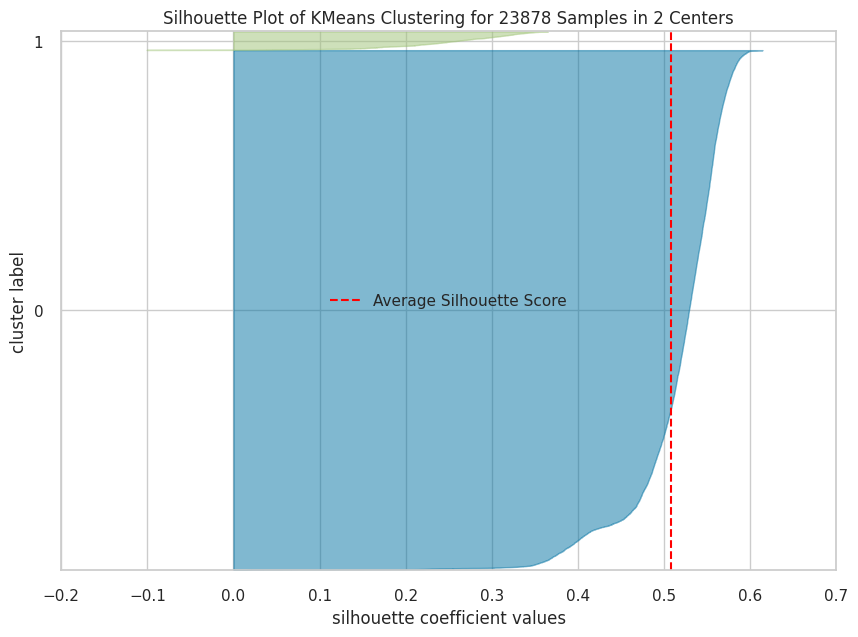

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 23878 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [147]:
from yellowbrick.cluster import SilhouetteVisualizer

# 1. Criar uma amostra de 20%
# Como X_reduced é um array NumPy, usamos len() para saber o tamanho
indices_amostra = np.random.choice(len(X_reduced),
                                   size=int(len(X_reduced) * 0.20),
                                   replace=False)

# CORREÇÃO: No NumPy, selecionas as linhas diretamente assim:
X_sample_viz = X_reduced[indices_amostra]

# 2. Configurar o Visualizador com o teu modelo (kmeans_final)
plt.figure(figsize=(10, 7))
visualizer = SilhouetteVisualizer(kmeans_final, colors='yellowbrick')

# 3. Ajustar à amostra
print("A gerar Silhouette Plot (NumPy mode)...")
visualizer.fit(X_sample_viz)
visualizer.show()

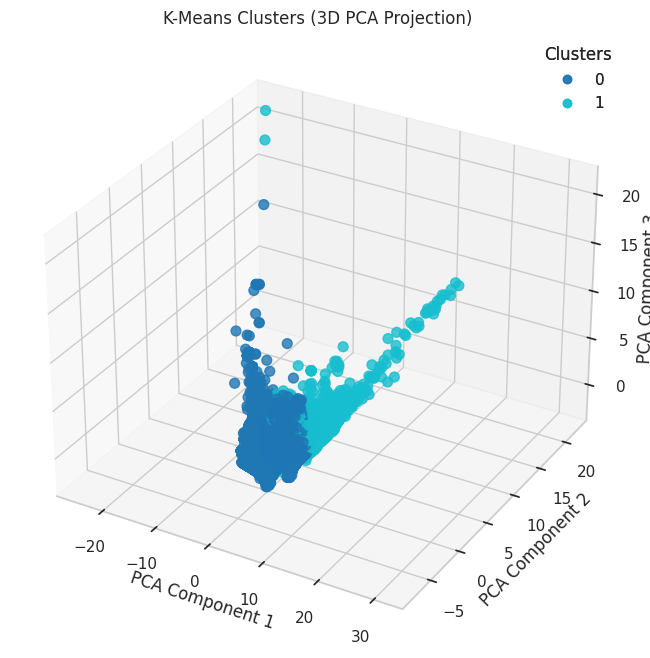

In [148]:
# -------------------------
# Reduce to 3D for visualization
# -------------------------
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(df_preprocessed)

# -------------------------
#  3D scatter plot
# -------------------------
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter with clusters
scatter = ax.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=cluster_labels, cmap='tab10', s=50, alpha=0.8
)

# Labels and title
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('K-Means Clusters (3D PCA Projection)')

# Legend
legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)

plt.show()

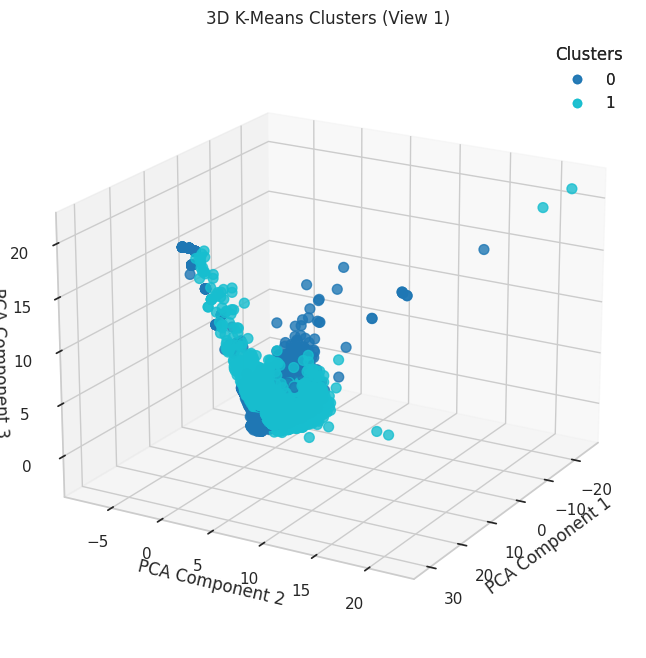

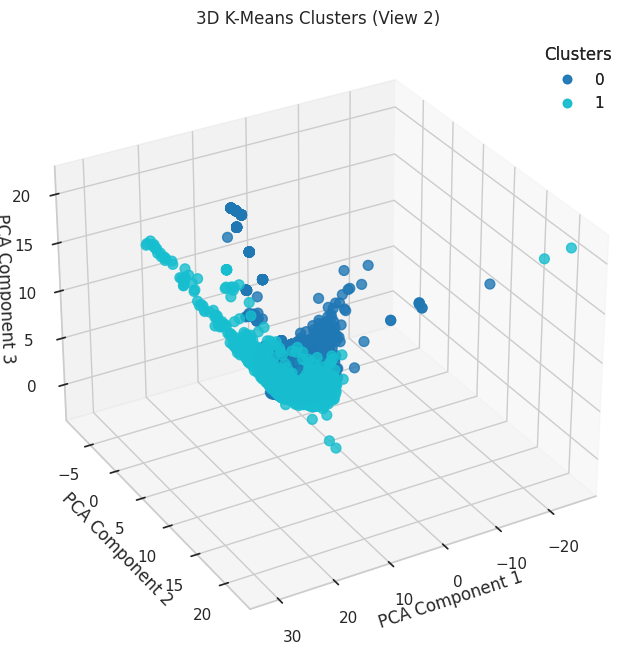

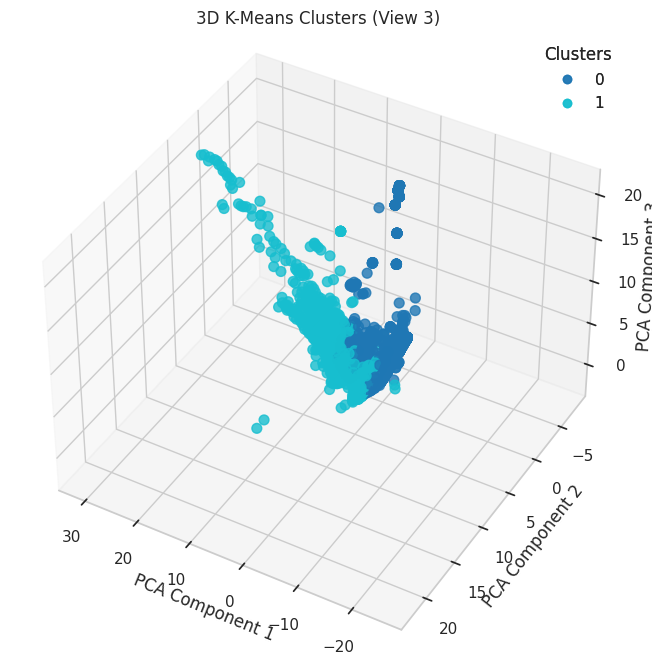

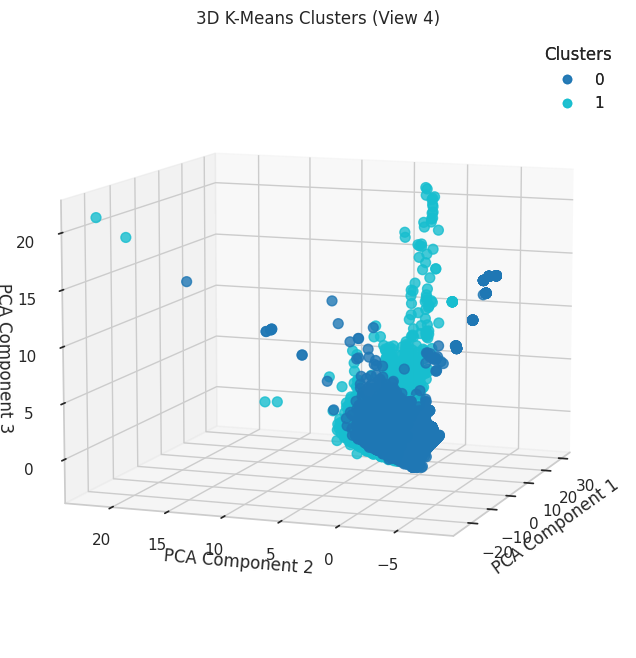

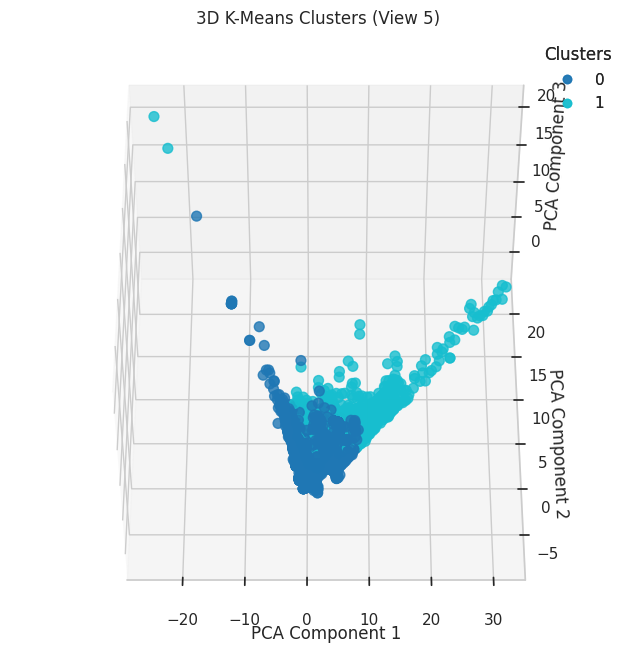

In [149]:
# Reduce to 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(df_preprocessed)

# Define some angles: (elevation, azimuth)
angles = [(20, 30), (30, 60), (40, 120), (10, 200), (50, 270)]

for i, (elev, azim) in enumerate(angles):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(
        X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
        c=cluster_labels, cmap='tab10', s=50, alpha=0.8
    )

    # Set labels and title
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.set_zlabel('PCA Component 3')
    ax.set_title(f'3D K-Means Clusters (View {i+1})')

    # Set the view angle
    ax.view_init(elev=elev, azim=azim)

    # Legend
    legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
    ax.add_artist(legend1)

    plt.show()


===== DISTRIBUIÇÃO POR PAÍS (Top 10 + Other) em % =====


country_top10,BEL,BRA,DEU,ESP,FRA,GBR,IRL,ITA,NLD,Other,PRT
cluster,,,,,,,,,,,
0,1.98,1.87,6.31,6.61,8.81,10.37,2.95,3.26,1.73,15.66,40.44
1,1.68,1.79,3.10,15.25,7.47,7.14,1.06,1.62,2.26,14.29,44.35


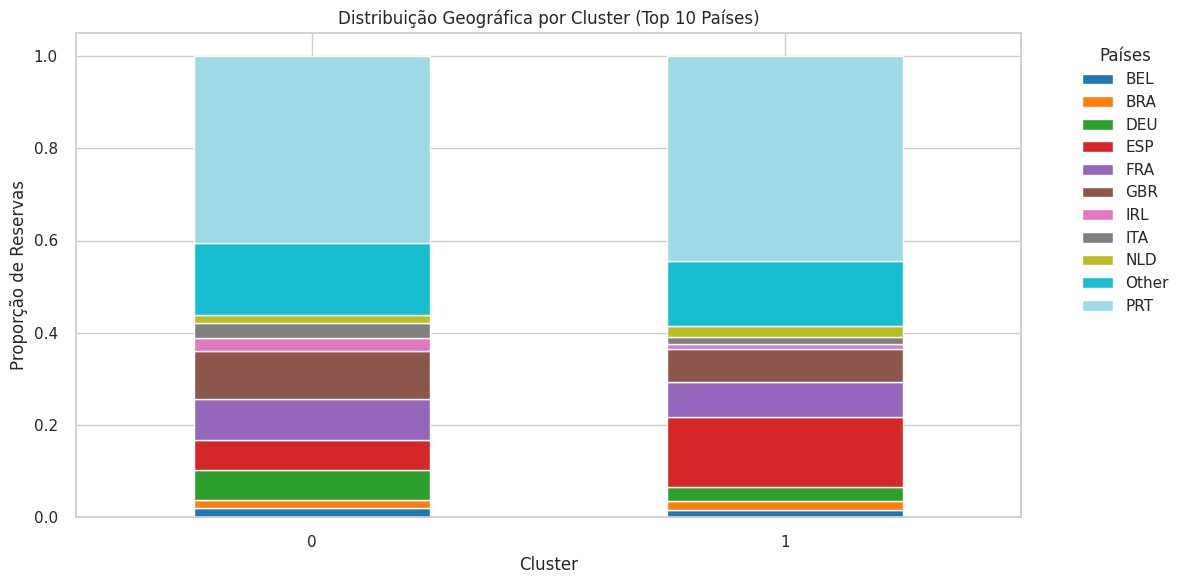

In [150]:
# 1. Identificar os 10 países com mais reservas no dataset
top_10_countries = df_profiling['country'].value_counts().nlargest(10).index

# 2. Criar uma coluna temporária que agrupa todos os outros países como 'Other'
df_profiling['country_top10'] = df_profiling['country'].apply(
    lambda x: x if x in top_10_countries else 'Other'
)

# 3. Criar a Tabela de Cruzamento (Crosstab) em Percentagem
# Isto mostra a distribuição geográfica dentro de cada cluster
counts = pd.crosstab(df_profiling['cluster'], df_profiling['country_top10'])
percentages = counts.div(counts.sum(axis=1), axis=0) * 100

print("\n===== DISTRIBUIÇÃO POR PAÍS (Top 10 + Other) em % =====")
display(percentages.round(2))

# 4. Visualização Gráfica (Stacked Bar Chart)
plt.figure(figsize=(12, 6))

# Criamos o gráfico de barras empilhadas diretamente da crosstab normalizada
ct = pd.crosstab(
    df_profiling['cluster'],
    df_profiling['country_top10'],
    normalize='index'
)

ct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')

plt.title("Distribuição Geográfica por Cluster (Top 10 Países)")
plt.xlabel("Cluster")
plt.ylabel("Proporção de Reservas")
plt.legend(title="Países", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0) # Manter o '0' e '1' na horizontal
plt.tight_layout()
plt.show()

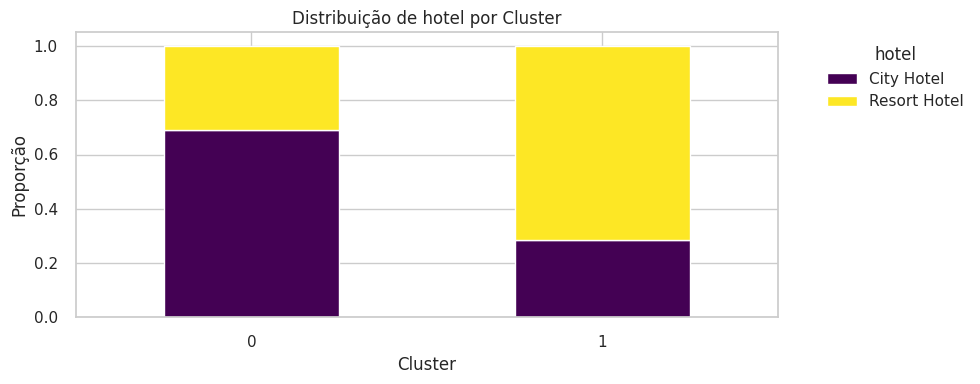

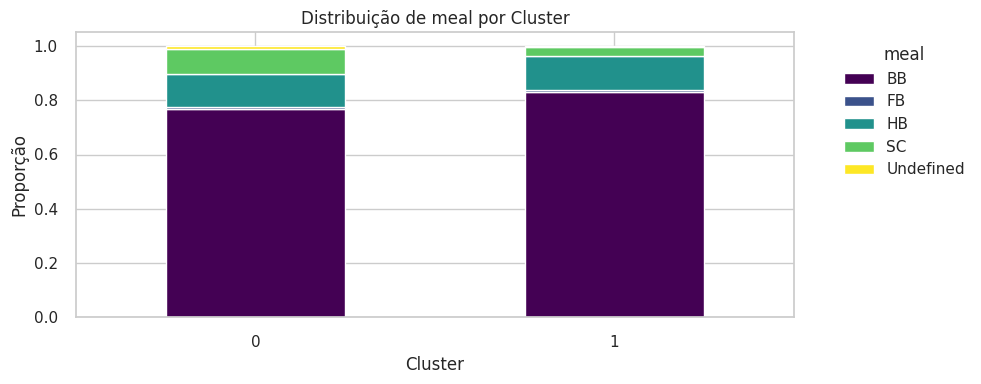

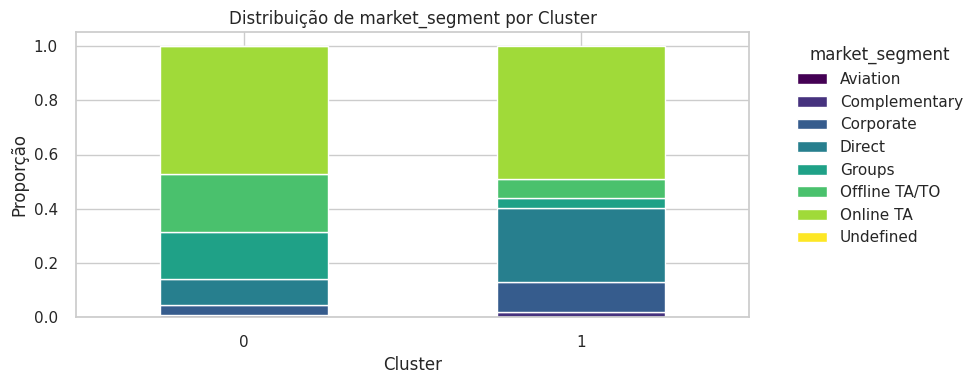

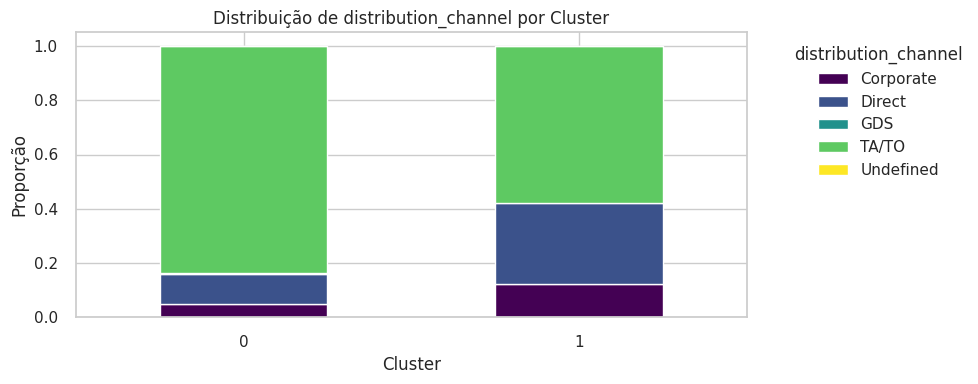

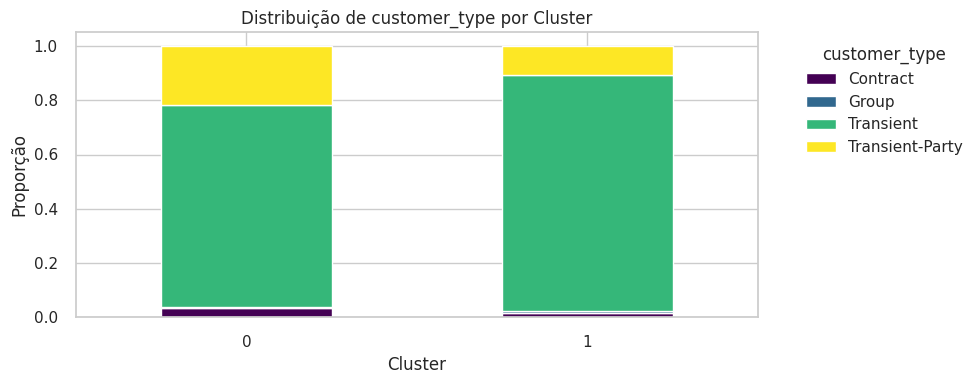

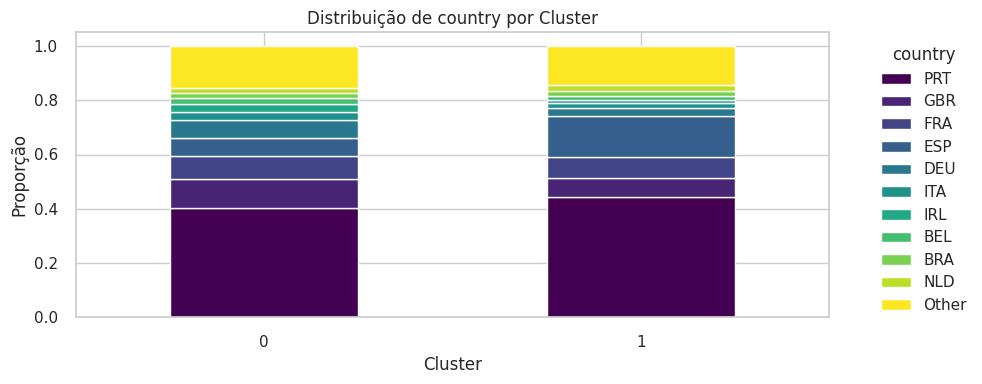

In [152]:
# Definir as variáveis que queremos visualizar
categorical_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'customer_type', 'country']

for col in categorical_cols:
    plt.figure(figsize=(10, 4))

    if col == "country":
        # Agrupar Top 10 países para o gráfico não ficar ilegível
        top_10 = df_profiling['country'].value_counts().nlargest(10).index.tolist()

        temp_col = df_profiling['country'].apply(
            lambda x: x if x in top_10 else "Other"
        )

        # Criar crosstab normalizada e ordenar colunas (Top 10 + Other)
        ct = pd.crosstab(df_profiling['cluster'], temp_col, normalize='index')
        ct = ct[top_10 + ['Other']]
    else:
        # Criar crosstab normalizada para as restantes variáveis
        ct = pd.crosstab(df_profiling['cluster'], df_profiling[col], normalize='index')

    # Gerar o gráfico de barras empilhadas (Stacked Bar)
    ct.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')

    plt.title(f"Distribuição de {col} por Cluster")
    plt.ylabel("Proporção")
    plt.xlabel("Cluster")
    plt.xticks(rotation=0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=col)

    plt.tight_layout()
    plt.show()

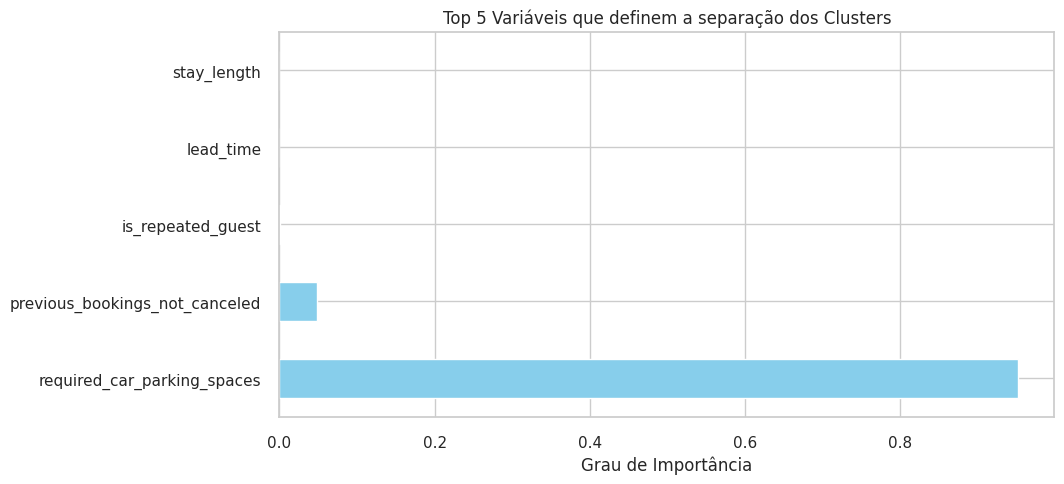

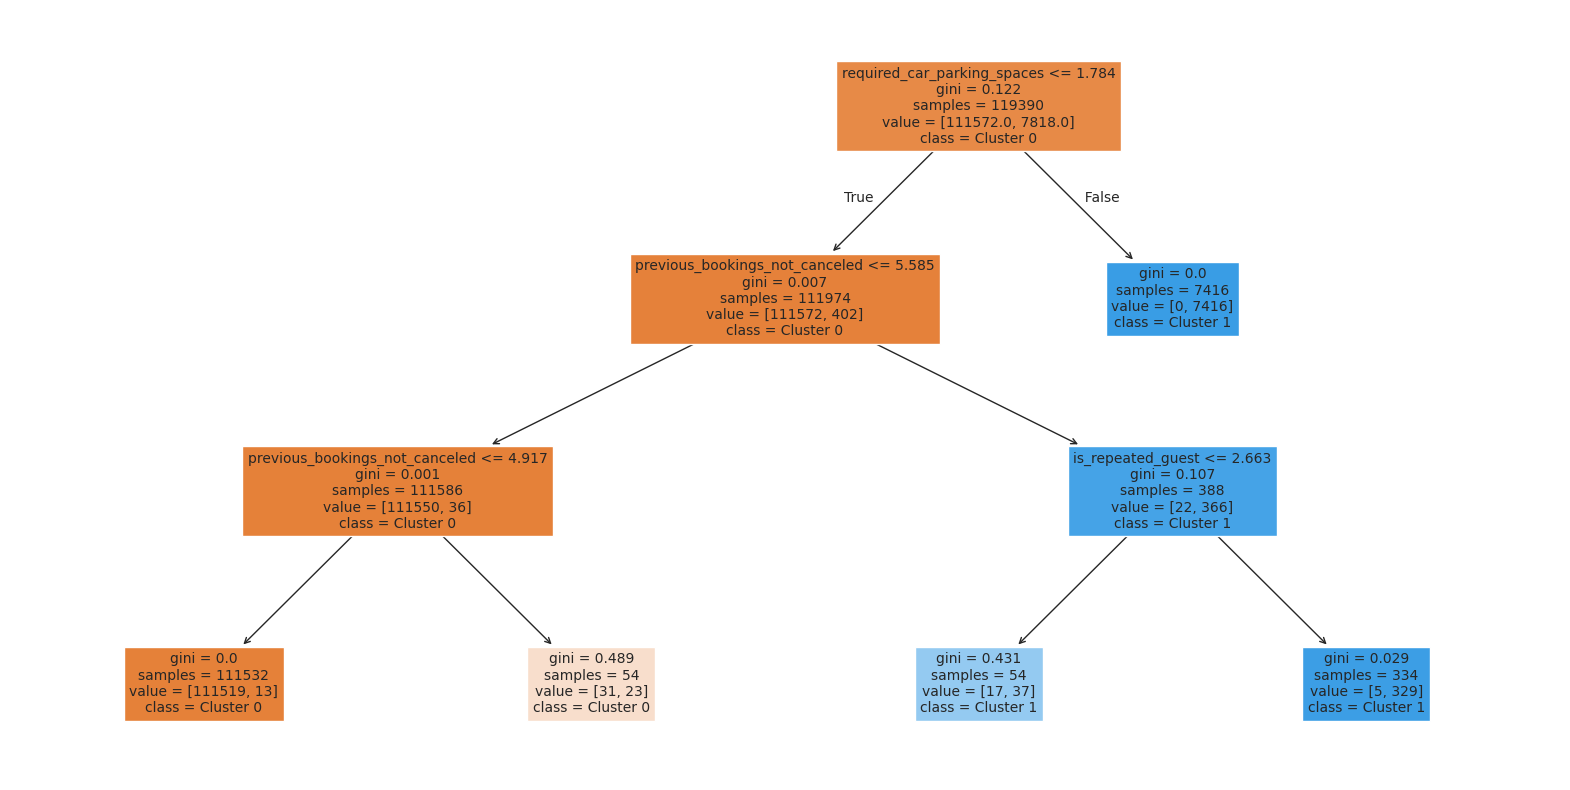

In [154]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# 1. Treinar uma árvore para explicar o cluster
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(df_preprocessed.drop(columns=['cluster']), df_preprocessed['cluster'])

# 2. Visualizar as variáveis mais importantes
features = df_preprocessed.drop(columns=['cluster']).columns
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='skyblue')
plt.title("Top 5 Variáveis que definem a separação dos Clusters")
plt.xlabel("Grau de Importância")
plt.show()

# 3. Desenhar a árvore (opcional, mas excelente para o relatório)
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=features, class_names=['Cluster 0', 'Cluster 1'], filled=True, fontsize=10)
plt.show()

In [155]:
# Criar coluna de Receita Perdida (ADR * Canceled)
df_profiling['revenue_lost'] = df_profiling['adr'] * df_profiling['is_canceled']

# Agrupar por cluster
revenue_impact = df_profiling.groupby('cluster').agg({
    'revenue_lost': 'sum',
    'adr': 'mean',
    'is_canceled': 'sum'
}).rename(columns={'is_canceled': 'total_canceled_rooms'})

print("### IMPACTO FINANCEIRO DOS CANCELAMENTOS ###")
display(revenue_impact.style.format("{:.2f}€"))

# Insight para o texto:
# "Embora o Cluster 1 cancele mais vezes, o Cluster 0 pode representar uma perda financeira maior
# por cada cancelamento devido ao ADR mais elevado."

### IMPACTO FINANCEIRO DOS CANCELAMENTOS ###


,revenue_lost,adr,total_canceled_rooms
cluster,,,
0,4639559.17€,101.25€,44182.00€
1,2383.50€,110.07€,42.00€
